In [45]:
## Problem Statement: 
#   "US corn farmers face a margin squeeze. This project identifies which Iowa counties are under the most financial pressure."


#   Data Sources: "Yield data from USDA Quick Stats API. Cost data from USDA ERS manual download (Heartland region proxy)."

#   Key Assumptions & Limitations: "Heartland regional cost used as proxy for Iowa. County-specific costs not available."

#   Conclusion: "All 82 counties in the dataset show negative margins for 2025. Taylor County is the most stressed, losing $255/acre."

In [104]:
## API call & data extraction
%pip install python-dotenv
import requests
import pandas as pd

import os
from dotenv import load_dotenv
load_dotenv()
API_KEY = os.getenv("USDA_API_KEY")
base_url = "https://quickstats.nass.usda.gov"

params = {
    "key": API_KEY,
    "commodity_desc": "CORN",
    "statisticcat_desc": "YIELD",
    "state_alpha": "IA",
    "year__GE": "2015",
    "format": "json"
}
response = requests.get(f"{base_url}/api/api_GET", params=params)

if response.status_code == 200:
    data = response.json()
    if "data" in data and len(data["data"]) > 0:
        df = pd.DataFrame(data["data"])
        print("Columns:", df.columns.tolist())
        print("\nFirst 10 rows:")
        print(df[["year", "state_name", "county_name", "commodity_desc", 
                  "statisticcat_desc", "unit_desc", "Value"]].head(10))
        print("\nTotal records:", len(df))
        print("\nUnique units:", df["unit_desc"].unique())
        print("\nUnique counties:", df["county_name"].nunique())
        print("\nValue range:", df["Value"].min(), "-", df["Value"].max())
    else:
        print("No data returned")
        print("Response:", data)
else:
    print("Error:", response.status_code, response.text)

Note: you may need to restart the kernel to use updated packages.
Columns: ['country_code', 'reference_period_desc', 'end_code', 'sector_desc', 'state_alpha', 'prodn_practice_desc', 'Value', 'congr_district_code', 'load_time', 'domaincat_desc', 'state_fips_code', 'commodity_desc', 'util_practice_desc', 'asd_code', 'unit_desc', 'watershed_code', 'short_desc', 'state_ansi', 'source_desc', 'zip_5', 'region_desc', 'country_name', 'class_desc', 'location_desc', 'domain_desc', 'county_ansi', 'CV (%)', 'group_desc', 'statisticcat_desc', 'state_name', 'asd_desc', 'year', 'county_name', 'watershed_desc', 'county_code', 'week_ending', 'begin_code', 'freq_desc', 'agg_level_desc']

First 10 rows:
   year state_name county_name commodity_desc statisticcat_desc    unit_desc  \
0  2018       IOWA                       CORN             YIELD    BU / ACRE   
1  2018       IOWA                       CORN             YIELD    BU / ACRE   
2  2018       IOWA                       CORN             YIELD  T

In [105]:
## Validating Data

import pandas as pd

# Continue from your existing df
print("Data shape:", df.shape)
print("\nYears present:", sorted(df["year"].unique()))
print("\nAggregation levels:", df["agg_level_desc"].unique())
print("\nDomain values:", df["domain_desc"].unique())
print("\nDomain categories:", df["domaincat_desc"].unique())
print("\nCommodity values:", df["commodity_desc"].unique())
print("\nStatistic categories:", df["statisticcat_desc"].unique())

# Check for missing county names
null_counties = df["county_name"].isnull().sum()
print(f"\nNull county names: {null_counties}")

# Inspect the county-level records with actual counties
county_df = df[df["county_name"].notna()]
print(f"\nRecords with county names: {len(county_df)}")
print("\nSample county records:")
print(county_df[["year", "county_name", "unit_desc", "Value"]].sort_values(by="year", ascending=True).head(10))

# Check for duplicates by county-year-unit
duplicates = county_df.duplicated(subset=["year", "county_name", "unit_desc"], keep=False)
print(f"\nDuplicate county-year-unit records: {duplicates.sum()}")

# Group to see how many counties per year
county_counts = county_df.groupby("year")["county_name"].nunique()
print("\nCounties per year:")
print(county_counts)

Data shape: (1442, 39)

Years present: [np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]

Aggregation levels: <StringArray>
['STATE', 'AGRICULTURAL DISTRICT', 'COUNTY']
Length: 3, dtype: str

Domain values: <StringArray>
['IRRIGATION METHOD, PRIMARY', 'TOTAL']
Length: 2, dtype: str

Domain categories: <StringArray>
['IRRIGATION METHOD, PRIMARY: (PRESSURE)', 'NOT SPECIFIED']
Length: 2, dtype: str

Commodity values: <StringArray>
['CORN']
Length: 1, dtype: str

Statistic categories: <StringArray>
['YIELD']
Length: 1, dtype: str

Null county names: 0

Records with county names: 1442

Sample county records:
      year                county_name    unit_desc  Value
1441  2015                             TONS / ACRE     24
417   2015                 WINNESHIEK    BU / ACRE  185.6
498   2015                        IDA    BU / ACRE  203.1
509   2015                    

In [106]:
# Find and examine duplicates
dups = df[df.duplicated(subset=["year", "county_name", "unit_desc"], keep=False)]
print("Duplicate records shape:", dups.shape)
print("\nDuplicate records sample:")
print(dups.sort_values(["year", "county_name", "unit_desc"])[["year", "county_name", "unit_desc", "Value", "agg_level_desc", "source_desc", "prodn_practice_desc"]])

# Count duplicates per year
print("\nDuplicate count by year:")
print(dups.groupby("year")["county_name"].count())

# Compare duplicate values
print("\nDuplicate value comparison (first two duplicates):")
dups_sorted = dups.sort_values(["year", "county_name", "unit_desc"])
for idx, row in dups_sorted.head(6).iterrows():
    print(f"{row['year']} {row['county_name']} {row['unit_desc']}: {row['Value']}")

Duplicate records shape: (217, 39)

Duplicate records sample:
      year county_name  unit_desc  Value         agg_level_desc source_desc  \
20    2015              BU / ACRE  202.5  AGRICULTURAL DISTRICT      SURVEY   
25    2015              BU / ACRE  198.9  AGRICULTURAL DISTRICT      SURVEY   
30    2015              BU / ACRE    194  AGRICULTURAL DISTRICT      SURVEY   
35    2015              BU / ACRE  193.1  AGRICULTURAL DISTRICT      SURVEY   
40    2015              BU / ACRE  194.8  AGRICULTURAL DISTRICT      SURVEY   
...    ...         ...        ...    ...                    ...         ...   
1070  2024              BU / ACRE    212                  STATE      SURVEY   
1062  2025              BU / ACRE    210                  STATE      SURVEY   
1063  2025              BU / ACRE    222                  STATE      SURVEY   
1064  2025              BU / ACRE    216                  STATE      SURVEY   
1065  2025              BU / ACRE    219                  STATE      

In [107]:
# Find rows where county_name is empty or whitespace
blank_counties = df[df["county_name"].str.strip() == ""]
print("Rows with blank county_name:", len(blank_counties))
print("\nSample blank county rows:")
print(blank_counties[["year", "state_name", "county_name", "agg_level_desc", "Value", "unit_desc"]].head(10))
print("\nAggregation levels in blank rows:")
print(blank_counties["agg_level_desc"].value_counts())

Rows with blank county_name: 170

Sample blank county rows:
   year state_name county_name agg_level_desc  Value    unit_desc
0  2018       IOWA                      STATE    203    BU / ACRE
1  2018       IOWA                      STATE    203    BU / ACRE
2  2018       IOWA                      STATE     25  TONS / ACRE
3  2018       IOWA                      STATE     25  TONS / ACRE
4  2022       IOWA                      STATE  182.5    BU / ACRE
5  2017       IOWA                      STATE  202.1    BU / ACRE
6  2022       IOWA                      STATE   20.8  TONS / ACRE
7  2017       IOWA                      STATE   23.6  TONS / ACRE
8  2022       IOWA                      STATE  199.2    BU / ACRE
9  2017       IOWA                      STATE  199.3    BU / ACRE

Aggregation levels in blank rows:
agg_level_desc
AGRICULTURAL DISTRICT    89
STATE                    81
Name: count, dtype: int64


In [108]:
# Filter to county-level records only
county_data = df[df["agg_level_desc"] == "COUNTY"].copy()
print("County records:", len(county_data))
print("County years:", sorted(county_data["year"].unique()))

# For state-level, filter to ALL PRODUCTION PRACTICES and average duplicates
state_data = df[(df["agg_level_desc"] == "STATE") & 
                (df["prodn_practice_desc"] == "ALL PRODUCTION PRACTICES")].copy()
print("\nState records before aggregation:", len(state_data))

# Ensure Value is numeric
state_data["Value"] = pd.to_numeric(state_data["Value"], errors="coerce")

# Aggregate
state_agg = state_data.groupby(["year", "unit_desc"], as_index=False)["Value"].mean()
print("State records after aggregation:", len(state_agg))
print("\nState aggregated values:")
print(state_agg.sort_values(["year", "unit_desc"]))

# Confirm no duplicates remain
dups_check = state_agg.duplicated(subset=["year", "unit_desc"], keep=False)
print(f"\nDuplicates remaining in state_agg: {dups_check.sum()}")

County records: 1272
County years: [np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]

State records before aggregation: 65
State records after aggregation: 22

State aggregated values:
    year    unit_desc   Value
0   2015    BU / ACRE  185.60
1   2015  TONS / ACRE   24.00
2   2016    BU / ACRE  198.60
3   2016  TONS / ACRE   24.00
4   2017    BU / ACRE  193.00
5   2017  TONS / ACRE   21.00
6   2018    BU / ACRE  201.20
7   2018  TONS / ACRE   20.50
8   2019    BU / ACRE  192.80
9   2019  TONS / ACRE   22.00
10  2020    BU / ACRE  188.00
11  2020  TONS / ACRE   20.50
12  2021    BU / ACRE  199.40
13  2021  TONS / ACRE   21.00
14  2022    BU / ACRE  201.40
15  2022  TONS / ACRE   21.00
16  2023    BU / ACRE  200.60
17  2023  TONS / ACRE   20.00
18  2024    BU / ACRE  211.80
19  2024  TONS / ACRE   24.00
20  2025    BU / ACRE  216.75
21  2025  TONS / ACRE   25.0

In [109]:
# Ensure Value is numeric globally
df["Value"] = pd.to_numeric(df["Value"], errors="coerce")

# ---- State level aggregation ----
state_data = df[(df["agg_level_desc"] == "STATE") & 
                (df["prodn_practice_desc"] == "ALL PRODUCTION PRACTICES")].copy()
state_agg = state_data.groupby(["year", "unit_desc"], as_index=False)["Value"].mean()
print("State aggregated (for reference):")
print(state_agg.sort_values(["year", "unit_desc"]))

# ---- County level cleaning ----
# Filter to county level, bushels per acre, and all production practices
county_filtered = df[
    (df["agg_level_desc"] == "COUNTY") &
    (df["unit_desc"] == "BU / ACRE") &
    (df["prodn_practice_desc"] == "ALL PRODUCTION PRACTICES")
].copy()

# Now group by year and county, take the mean of Value to handle any remaining duplicates (e.g., from different sources)
county_final = county_filtered.groupby(["year", "county_name"], as_index=False)["Value"].mean()

# Rename for clarity
county_final.rename(columns={"Value": "yield_bu_per_acre"}, inplace=True)

print(f"\nCounty final records: {len(county_final)}")
print("Years covered:", sorted(county_final["year"].unique()))
print("\nSample counties per year:")
print(county_final.groupby("year").size().head(10))
print("\nFirst 10 rows of county_final:")
print(county_final.sort_values(["year", "county_name"]).head(10))

# Save to CSV for later use
county_final.to_csv("iowa_corn_yield_county.csv", index=False)
print("\nSaved to iowa_corn_yield_county.csv")

State aggregated (for reference):
    year    unit_desc   Value
0   2015    BU / ACRE  185.60
1   2015  TONS / ACRE   24.00
2   2016    BU / ACRE  198.60
3   2016  TONS / ACRE   24.00
4   2017    BU / ACRE  193.00
5   2017  TONS / ACRE   21.00
6   2018    BU / ACRE  201.20
7   2018  TONS / ACRE   20.50
8   2019    BU / ACRE  192.80
9   2019  TONS / ACRE   22.00
10  2020    BU / ACRE  188.00
11  2020  TONS / ACRE   20.50
12  2021    BU / ACRE  199.40
13  2021  TONS / ACRE   21.00
14  2022    BU / ACRE  201.40
15  2022  TONS / ACRE   21.00
16  2023    BU / ACRE  200.60
17  2023  TONS / ACRE   20.00
18  2024    BU / ACRE  211.80
19  2024  TONS / ACRE   24.00
20  2025    BU / ACRE  216.75
21  2025  TONS / ACRE   25.00

County final records: 995
Years covered: [np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]

Sample counties per year:
year
2015    96
2016    99
201

In [110]:
# for automation, i will use this data pull method instead of manual csv file path...

dff = county_final[county_final["year"] == 2025].copy()

In [111]:
dff.shape
dff.head()

,year,county_name,yield_bu_per_acre
915,2025,ADAIR,187.0
916,2025,ALLAMAKEE,211.1
917,2025,AUDUBON,224.7
918,2025,BLACK HAWK,207.2
919,2025,BOONE,209.9


In [112]:
## Margin Calculating

# This requires a manual step since there is no direct api for automation
import os

file_path = 'CornCostReturn.xlsx'

if not os.path.exists(file_path):
    print("ERROR: CornCostReturn.xlsx not found.")
    print("Please download the file from ERS website and paste it in the same project folder.")
    print("Download link: https://www.ers.usda.gov/data-products/commodity-costs-and-returns/")
    print("Look for the 'Recent Cost and Returns' table and download the 'Corn' Excel file.")
    print("Rename the file to CornCostReturn.xlsx if necessary.")
else:
    print("File Found. Reading cost data.....")
    # Run this command in terminal if you get openpyxl error :     pip install openpyxl        OR       %pip install openpyxl
    cost_df = pd.read_excel('CornCostReturn.xlsx', sheet_name = 'Data sheet (machine readable)')

    # Extracting total cost for Heartland 2025
    cost_row = cost_df[(cost_df["Region"] == "Heartland") &
           (cost_df["Year"] == 2025) &
            (cost_df["Item"] == "Total, costs listed")]

    cost_per_acre = cost_row["Value"].values[0]

    # Extracting price for Heartland 2025

    price_row = cost_df[(cost_df["Region"] == "Heartland") &
            (cost_df["Year"] == 2025) &
            (cost_df["Item"] == 'Price')]

    price_per_bu = price_row["Value"].values[0]

    print(f"Heartland 2025 : Cost per acre = ${cost_per_acre:.2f}, Price per bushel = ${price_per_bu:.2f}")

    # calculating margin for 2025
    dff = county_final[county_final["year"] == 2025].copy()
    dff['margin'] = (dff['yield_bu_per_acre'] * price_per_bu) - cost_per_acre

    # sorting in ascending order
    dff_sorted = dff.sort_values("margin")

    print("\nTop 10 most stressed counties in iowa (lowest / most negative margin):")
    print(dff_sorted[["county_name", "yield_bu_per_acre", "margin"]].head(10))

    # saving ranked list
    dff_sorted.to_csv('iowa_county_margins_2025.csv', index=False)
    print("\nRanked list saved to 'iowa_county_margins_2025.csv'.")


File Found. Reading cost data.....
Heartland 2025 : Cost per acre = $947.29, Price per bushel = $3.92

Top 10 most stressed counties in iowa (lowest / most negative margin):
    county_name  yield_bu_per_acre   margin
984      TAYLOR              176.6 -255.018
936     DECATUR              182.9 -230.322
964       LUCAS              183.4 -228.362
950    HARRISON              186.2 -217.386
971      MONROE              186.4 -216.602
915       ADAIR              187.0 -214.250
925        CASS              188.4 -208.762
994      WRIGHT              190.2 -201.706
968       MILLS              190.4 -200.922
935       DAVIS              192.3 -193.474

Ranked list saved to 'iowa_county_margins_2025.csv'.


In [113]:
## RESULT & EDA
#%pip install matplotlib
import matplotlib.pyplot as plt

# === 1. Summary Statistics ===
print("=== SUMMARY STATISTICS ===")
print("\nYield (bu/acre):")
print(dff['yield_bu_per_acre'].describe())
print("\nMargin ($/acre):")
print(dff['margin'].describe())


=== SUMMARY STATISTICS ===

Yield (bu/acre):
count     80.000000
mean     209.026250
std       12.525293
min      176.600000
25%      202.150000
50%      210.100000
75%      217.600000
max      233.800000
Name: yield_bu_per_acre, dtype: float64

Margin ($/acre):
count     80.00000
mean    -127.90710
std       49.09915
min     -255.01800
25%     -154.86200
50%     -123.69800
75%      -94.29800
max      -30.79400
Name: margin, dtype: float64


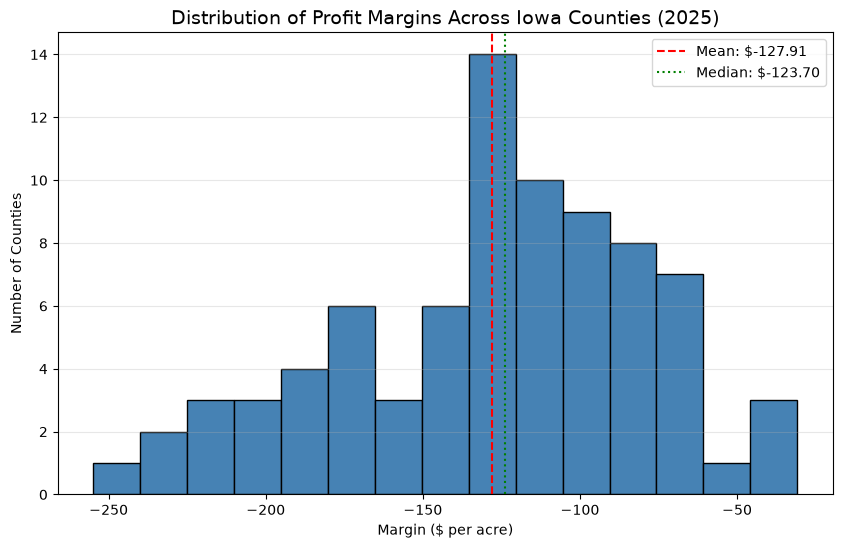

In [114]:
# === 2. Histogram of Margins ===
plt.figure(figsize=(10,6))
plt.hist(dff['margin'], bins=15, edgecolor='black', color='steelblue')
plt.title('Distribution of Profit Margins Across Iowa Counties (2025)', fontsize=14)
plt.xlabel('Margin ($ per acre)')
plt.ylabel('Number of Counties')
plt.axvline(x=dff['margin'].mean(), color='red', linestyle='dashed', label=f'Mean: ${dff["margin"].mean():.2f}')
plt.axvline(x=dff['margin'].median(), color='green', linestyle='dotted', label=f'Median: ${dff["margin"].median():.2f}')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

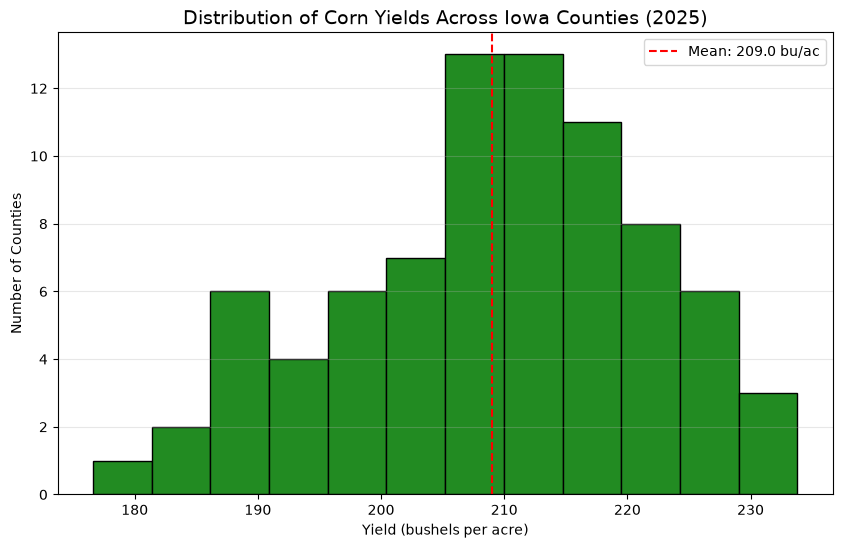

In [115]:
# === 3. Histogram of Yields ===
plt.figure(figsize=(10,6))
plt.hist(dff['yield_bu_per_acre'], bins=12, edgecolor='black', color='forestgreen')
plt.title('Distribution of Corn Yields Across Iowa Counties (2025)', fontsize=14)
plt.xlabel('Yield (bushels per acre)')
plt.ylabel('Number of Counties')
plt.axvline(x=dff['yield_bu_per_acre'].mean(), color='red', linestyle='dashed', label=f'Mean: {dff["yield_bu_per_acre"].mean():.1f} bu/ac')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

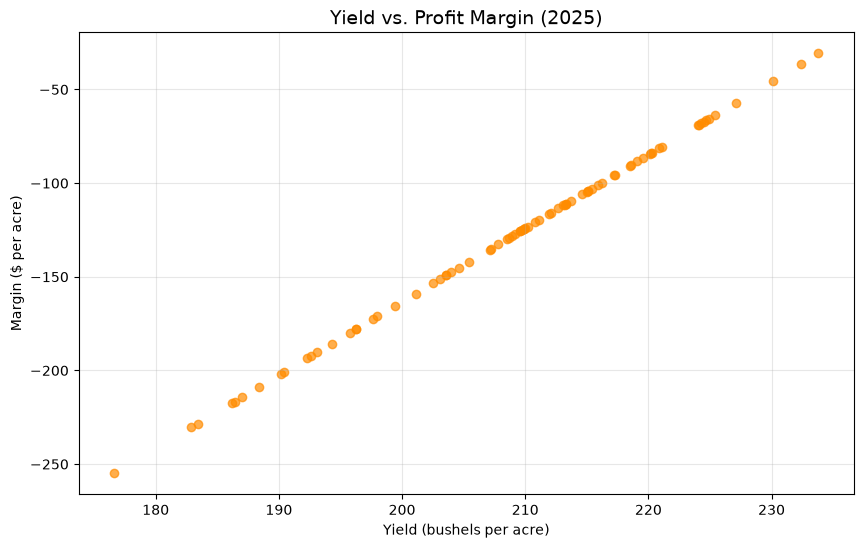

In [116]:
# === 4. Scatter Plot: Yield vs Margin ===
plt.figure(figsize=(10,6))
plt.scatter(dff['yield_bu_per_acre'], dff['margin'], alpha=0.7, color='darkorange')
plt.title('Yield vs. Profit Margin (2025)', fontsize=14)
plt.xlabel('Yield (bushels per acre)')
plt.ylabel('Margin ($ per acre)')
plt.grid(alpha=0.3)
plt.show()


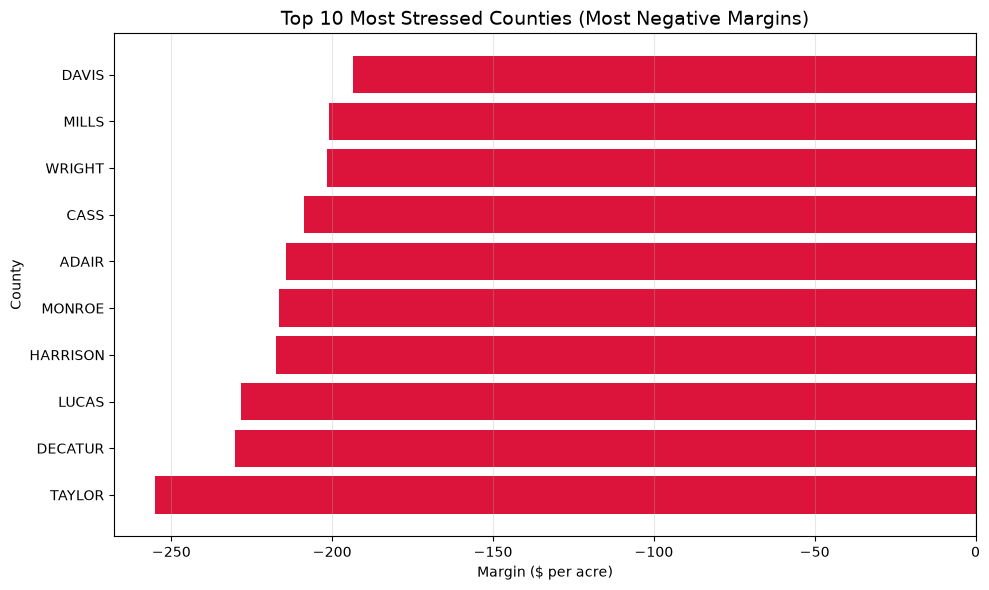

In [117]:
# === 5. Top 10 Worst Counties (Bar Chart) ===
worst = dff_sorted.head(10)
plt.figure(figsize=(10,6))
plt.barh(worst['county_name'], worst['margin'], color='crimson')
plt.title('Top 10 Most Stressed Counties (Most Negative Margins)', fontsize=14)
plt.xlabel('Margin ($ per acre)')
plt.ylabel('County')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

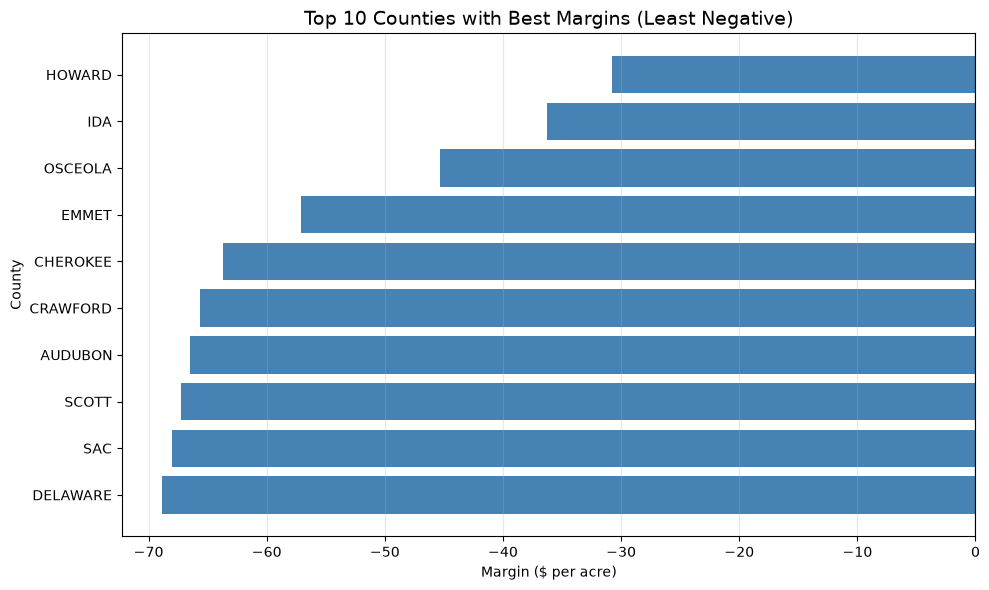

In [118]:
# === 6. Top 10 Best Counties (Least Negative) ===
best = dff_sorted.tail(10)
plt.figure(figsize=(10,6))
plt.barh(best['county_name'], best['margin'], color='steelblue')
plt.title('Top 10 Counties with Best Margins (Least Negative)', fontsize=14)
plt.xlabel('Margin ($ per acre)')
plt.ylabel('County')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [119]:
print("\n=== KEY INSIGHTS ===")
print(f"1. All {len(dff)} counties have negative margins in 2025.")
print(f"2. The worst margin is ${dff['margin'].min():.2f} (Taylor County).")
print(f"3. The best (least negative) margin is ${dff['margin'].max():.2f} (Howard County).")
print(f"4. The average loss across all counties is ${dff['margin'].mean():.2f} per acre.")
print(f"5. The scatter plot confirms margin is a linear function of yield, as expected.")


=== KEY INSIGHTS ===
1. All 80 counties have negative margins in 2025.
2. The worst margin is $-255.02 (Taylor County).
3. The best (least negative) margin is $-30.79 (Howard County).
4. The average loss across all counties is $-127.91 per acre.
5. The scatter plot confirms margin is a linear function of yield, as expected.


In [120]:
# geopandas map for better visualisation
#%pip install geopandas

import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import requests
import zipfile
import os
import io

# downloading iowa county shape file from us census
url = "https://www2.census.gov/geo/tiger/GENZ2024/shp/cb_2024_us_county_500k.zip"
if not os.path.exists("cb_2023_19_county_500k.shp"):
    print("Downloading shapefile...")
    response = requests.get(url)
    with zipfile.ZipFile(io.BytesIO(response.content)) as z:
        z.extractall(".")
    print("Download Complete")
else:
    print("Shapefile already exists")

# loading the shapefile
shapefile_name = "cb_2024_us_county_500k.shp"
gdf = gpd.read_file(shapefile_name)

# normalising county names 
gdf['county_name'] = gdf['NAME'].str.upper().str.strip()
dff_sorted['county_name'] = dff_sorted['county_name'].str.upper().str.strip()

# merging data into geodf

merged = gdf.merge(dff_sorted, on="county_name", how="left")


Download Complete


In [121]:

#%pip install folium

import folium
import geopandas as gpd
import pandas as pd

# 1. Filter to Iowa only (FIPS code 19)
iowa = merged[merged['STATEFP'] == '19'].copy()

# 2. Drop counties with no margin data 
iowa = iowa.dropna(subset=['margin'])

# 3.  interactive map
m = folium.Map(location=[42.0, -93.5], zoom_start=7, tiles='OpenStreetMap')

# 4. choropleth layer
folium.Choropleth(
    geo_data=iowa,
    name='choropleth',
    data=iowa,
    columns=['county_name', 'margin'],
    key_on='feature.properties.county_name',
    fill_color='Reds_r',           # Reversed Reds – dark = worst loss
    fill_opacity=0.7,
    line_opacity=0.2,
    legend_name='Profit Margin ($ per acre)'
).add_to(m)

# 5. Add hover tooltips 
folium.GeoJson(
    iowa,
    style_function=lambda feature: {
        'fillColor': 'transparent',
        'color': 'black',
        'weight': 0.5,
        'dashArray': '5, 5'
    },
    tooltip=folium.GeoJsonTooltip(
        fields=['county_name', 'margin'],
        aliases=['County:', 'Margin ($/acre):'],
        localize=True
    )
).add_to(m)

# 6. Display the map
display(m)


In [122]:
# South western counties faced significant losses ($179-$255)
# Eastern and north eastern counties were lesser stressed than their southern counterparts.


In [123]:
## Time-Series 

county_final["year"].unique()

#extracting cost and price for year 2015 manually

cost_row_2015 = cost_df[(cost_df['Year'] == 2015) & (cost_df['Region'] == 'Heartland') & (cost_df['Item'] == 'Total, costs listed')]
cost_per_acre_2015 = cost_row_2015["Value"].values[0]

price_row_2015 = cost_df[(cost_df["Year"] == 2015) & (cost_df["Region"] == "Heartland") & (cost_df["Item"] == "Price")]
price_per_bu_2015 = price_row_2015["Value"].values[0]
print(f"Cost of Corn Production in 2015 : ${cost_per_acre_2015}")
print(f"Price per bushel in 2015 : ${price_per_bu_2015}")

#margin for 2015

dff = county_final[county_final["year"] == 2015].copy()
dff['margin'] = (dff['yield_bu_per_acre']* price_per_bu_2015) - cost_per_acre_2015

dfsorted = dff.sort_values('margin')
dfsorted.head()

Cost of Corn Production in 2015 : $708.4
Price per bushel in 2015 : $3.64


,year,county_name,yield_bu_per_acre,margin
25,2015,DAVIS,142.4,-190.064
55,2015,LEE,145.1,-180.236
78,2015,RINGGOLD,147.8,-170.408
19,2015,CLARKE,152.4,-153.664
3,2015,APPANOOSE,154.3,-146.748


In [124]:
# looping for all 10 years of data

years = range(2015,2026)
county_margins = {}

for year in years:
    cost_row_ = cost_df[(cost_df['Year'] == year) & (cost_df['Region'] == 'Heartland') & (cost_df['Item'] == 'Total, costs listed')]
    cost_per_acre_ = cost_row_["Value"].values[0]
        
    price_row_ = cost_df[(cost_df["Year"] == year) & (cost_df["Region"] == "Heartland") & (cost_df["Item"] == "Price")]
    price_per_bu_ = price_row_["Value"].values[0]
    
    if cost_row_.empty or price_row_.empty:
        print(f"Missing data for year: {year}, skipping...")
        continue
        
    df_year = county_final[county_final["year"] == year].copy()
    df_year['margin'] = ((df_year['yield_bu_per_acre']* price_per_bu_) - cost_per_acre_)
        
    print(f"Cost of Corn Production in {year} : ${cost_per_acre_}")
    print(f"Price per bushel in {year} : ${price_per_bu_}")
    print(f"Margin in {year} : ${df_year['margin'].mean():.2f} per acre (avg)")

Cost of Corn Production in 2015 : $708.4
Price per bushel in 2015 : $3.64
Margin in 2015 : $-24.21 per acre (avg)
Cost of Corn Production in 2016 : $712.1
Price per bushel in 2016 : $3.28
Margin in 2016 : $-55.63 per acre (avg)
Cost of Corn Production in 2017 : $698.83
Price per bushel in 2017 : $3.23
Margin in 2017 : $-59.48 per acre (avg)
Cost of Corn Production in 2018 : $715.89
Price per bushel in 2018 : $3.39
Margin in 2018 : $-61.52 per acre (avg)
Cost of Corn Production in 2019 : $724.79
Price per bushel in 2019 : $3.8
Margin in 2019 : $13.24 per acre (avg)
Cost of Corn Production in 2020 : $706.01
Price per bushel in 2020 : $3.59
Margin in 2020 : $-77.67 per acre (avg)
Cost of Corn Production in 2021 : $783.59
Price per bushel in 2021 : $5.02
Margin in 2021 : $222.34 per acre (avg)
Cost of Corn Production in 2022 : $984.48
Price per bushel in 2022 : $6.42
Margin in 2022 : $267.64 per acre (avg)
Cost of Corn Production in 2023 : $968.66
Price per bushel in 2023 : $4.88
Margin in

In [125]:
#%pip install seaborn
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

years = range(2015, 2026)
all_margins = []

for year in years:
    cost_row = cost_df[(cost_df['Year'] == year) & 
                       (cost_df['Region'] == 'Heartland') & 
                       (cost_df['Item'] == 'Total, costs listed')]
    price_row = cost_df[(cost_df['Year'] == year) & 
                        (cost_df['Region'] == 'Heartland') & 
                        (cost_df['Item'] == 'Price')]
    
    if cost_row.empty or price_row.empty:
        continue
        
    cost_per_acre = cost_row['Value'].values[0]
    price_per_bu  = price_row['Value'].values[0]
    
    df_year = county_final[county_final['year'] == year].copy()
    df_year['margin'] = df_year['yield_bu_per_acre'] * price_per_bu - cost_per_acre
    all_margins.append(df_year)

margins_all = pd.concat(all_margins, ignore_index=True)

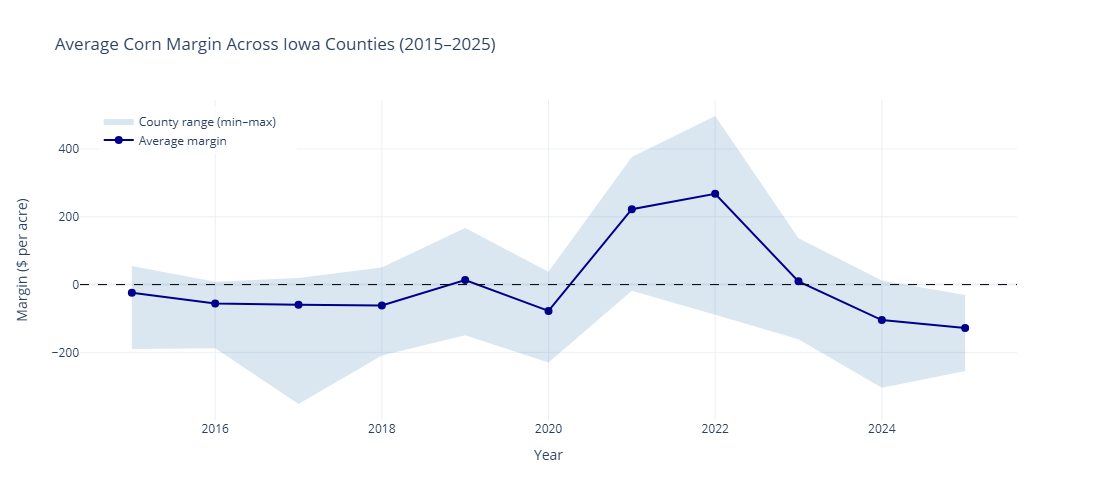

In [126]:
import plotly.graph_objects as go

# Compute yearly aggregates
avg_margin = margins_all.groupby('year')['margin'].mean()
min_margin = margins_all.groupby('year')['margin'].min()
max_margin = margins_all.groupby('year')['margin'].max()

# Create figure
fig = go.Figure()

# Add shaded range (min–max) using a filled area trace
fig.add_trace(go.Scatter(
    x=avg_margin.index.tolist() + avg_margin.index[::-1].tolist(),
    y=max_margin.tolist() + min_margin[::-1].tolist(),
    fill='toself',
    fillcolor='rgba(70, 130, 180, 0.2)',  # steelblue with alpha
    line=dict(color='rgba(255,255,255,0)'),
    name='County range (min–max)',
    showlegend=True,
    hoverinfo='skip'  # avoids clutter on hover
))

# Add average line
fig.add_trace(go.Scatter(
    x=avg_margin.index,
    y=avg_margin.values,
    mode='lines+markers',
    name='Average margin',
    line=dict(color='darkblue', width=2),
    marker=dict(size=8),
    hovertemplate='Year: %{x}<br>Average: $%{y:.2f}<extra></extra>'
))

# Add zero line
fig.add_hline(y=0, line_dash="dash", line_color="black", line_width=1)

# Layout
fig.update_layout(
    title='Average Corn Margin Across Iowa Counties (2015–2025)',
    xaxis_title='Year',
    yaxis_title='Margin ($ per acre)',
    hovermode='x unified',
    legend=dict(x=0.02, y=0.98, bgcolor='rgba(255,255,255,0.8)'),
    template='plotly_white',
    height=500,
    width=900
)

fig.show()

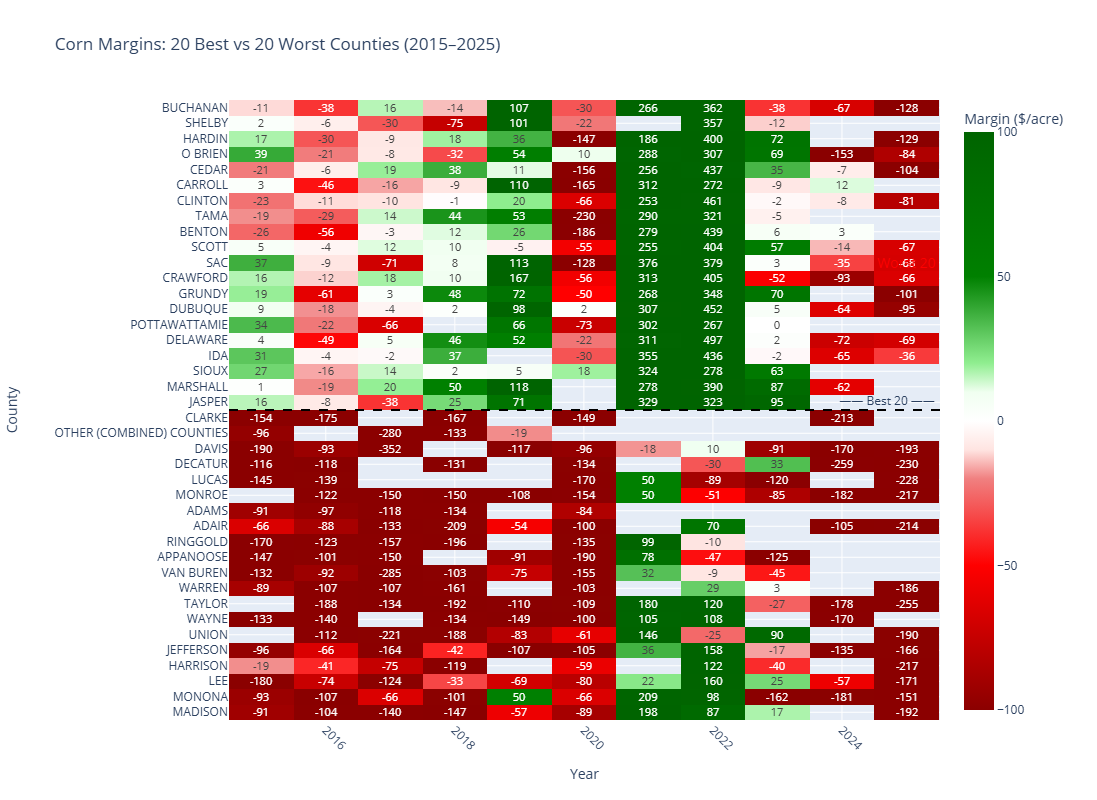

In [127]:
import plotly.express as px
import plotly.graph_objects as go

# 1. Get average margin per county and select 20 best/worst
avg_margin = margins_all.groupby('county_name')['margin'].mean().sort_values()
worst_20 = avg_margin.head(20).index
best_20 = avg_margin.tail(20).index
selected_counties = list(best_20) + list(worst_20)

# 2. Build pivot and filter
heatmap_data = margins_all.pivot(index='county_name', columns='year', values='margin')
heatmap_data = heatmap_data.loc[selected_counties]

# 3. Clip the color range to a tight window around zero.
#    This makes even small margins (like +$10 or -$10) clearly visible.
zmin, zmax = -100, 100

# 4. Custom diverging colorscale: negative → red, zero → white, positive → green
custom_colorscale = [
    [0.00, "darkred"],
    [0.25, "red"],
    [0.40, "lightcoral"],
    [0.45, "mistyrose"],
    [0.50, "white"],        # zero → white
    [0.55, "honeydew"],
    [0.60, "lightgreen"],
    [0.75, "green"],
    [1.00, "darkgreen"]
]

# 5. Create heatmap
fig = px.imshow(
    heatmap_data,
    labels=dict(x="Year", y="County", color="Margin ($/acre)"),
    color_continuous_scale=custom_colorscale,
    zmin=zmin,
    zmax=zmax,
    title="Corn Margins: 20 Best vs 20 Worst Counties (2015–2025)",
    aspect="auto",
    text_auto='.0f'
)

# 6. Separator line and annotations
fig.add_hline(
    y=19.5,
    line_dash="dash",
    line_color="black",
    annotation_text="—— Best 20 ——",
    annotation_position="top right"
)
fig.add_annotation(
    x=2025,
    y=10,
    text="Worst 20",
    showarrow=False,
    font=dict(color="red", size=14)
)

# 7. Layout
fig.update_layout(
    height=800,
    xaxis={'tickangle': 45}
)

fig.show()

In [128]:
# Conclusion
# Statistically, Corn farming in the US is a risky business in 2026.
# In the past 3 years, counties in IOWA faced severe downturn in margin going from $267/acre to -$127/acre...  
# ....A $395/acre reversal that has put every county in the red
# Historically, 2021 and 2022 had $222-$267 average margin per acre, but 2025 shows a severse downturn across all counties.